# <font color="#0099CC">**Sistema neuronal confiable para concesión de crédito**</font>

Este notebook ejecuta el MVP completo del taller **B4-T1: Diseño de Redes Neuronales Confiables** sobre Home Credit Default Risk. El flujo cubre las cuatro obligaciones del enunciado: arquitectura customizada, aprendizaje justo, AutoML e incertidumbre.

## <font color="#0099CC">**0. Configuración global y contrato de ejecución**</font>

Esta celda fija rutas, semillas, estilo visual e hiperparámetros principales. La variable `RUN_FULL_PIPELINE=True` deja claro que el notebook entrena de verdad: ejecuta Keras Tuner, el barrido FAIR, los modelos finales y M2 de incertidumbre.

La seguridad del flujo está en el contrato de rutas: nada se escribe en `results/tables`, `results/models` ni en `kt_dir` de la raíz. Todo queda dentro del `run_id` de esta ejecución.


In [1]:
from pathlib import Path
import os
import random
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_RAW = PROJECT_ROOT / "data" / "raw"
APPLICATION_TRAIN = DATA_RAW / "application_train.csv"

# Si RUN_ID es None, se crea automáticamente un identificador temporal YYYYMMDD_HHMMSS.
RUN_ID = None
RUN_FULL_PIPELINE = True
SEED = 42

MAX_TRIALS = 15
EPOCHS = 50
BATCH_SIZE = 1024
LAMBDA_VALUES = (0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0)

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

try:
    import tensorflow as tf
    tf.keras.utils.set_random_seed(SEED)
except Exception as exc:  # pragma: no cover - notebook diagnostic only
    print("Aviso: no se pudo fijar la semilla de TensorFlow:", exc)

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = True
warnings.filterwarnings("ignore", category=FutureWarning)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("APPLICATION_TRAIN:", APPLICATION_TRAIN)
print("RUN_FULL_PIPELINE:", RUN_FULL_PIPELINE)
print("MAX_TRIALS:", MAX_TRIALS, "EPOCHS:", EPOCHS, "BATCH_SIZE:", BATCH_SIZE)



PROJECT_ROOT: c:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani
APPLICATION_TRAIN: c:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\data\raw\application_train.csv
RUN_FULL_PIPELINE: True
MAX_TRIALS: 15 EPOCHS: 50 BATCH_SIZE: 1024


In [2]:
from src.trustworthy_credit.reproducible_run import (
    ReproducibleMVPConfig,
    ReproducibleMVPWorkflow,
    ReproducibleRunPaths,
)

paths = ReproducibleRunPaths(project_root=PROJECT_ROOT, run_id=RUN_ID)
config = ReproducibleMVPConfig(
    seed=SEED,
    lambda_values=LAMBDA_VALUES,
    max_trials=MAX_TRIALS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    tuning_lambda_fair=0.5,
    tuner_project_name="fair_credit_mvp_final",
    uncertainty_epochs=50,
)
workflow = ReproducibleMVPWorkflow(
    project_root=PROJECT_ROOT,
    paths=paths,
    config=config,
)

def save_run_figure(fig, name: str) -> Path:
    """Guarda una figura dentro de la carpeta aislada del run actual."""
    path = paths.figures_dir / name
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

assert paths.tables_dir != PROJECT_ROOT / "results" / "tables"
assert paths.figures_dir != PROJECT_ROOT / "results" / "figures"
assert paths.models_dir != PROJECT_ROOT / "results" / "models"
assert paths.tuner_dir != PROJECT_ROOT / "kt_dir"
assert str(paths.tables_dir).endswith(str(Path("results") / "runs" / paths.run_id / "tables"))

print("RUN_ID:", paths.run_id)
print("RUN_DIR:", paths.run_dir)
print("TABLES:", paths.tables_dir)
print("FIGURES:", paths.figures_dir)
print("MODELS:", paths.models_dir)
print("KT_DIR:", paths.tuner_dir)


RUN_ID: 20260624_214719
RUN_DIR: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719
TABLES: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719\tables
FIGURES: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719\figures
MODELS: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719\models
KT_DIR: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719\kt_dir


## <font color="#0099CC">**1. Datos, objetivo y lectura inicial**</font>

El problema es binario: `TARGET=1` indica dificultad de pago y `TARGET=0` pago puntual. La variable sensible usada para auditar justicia es `CODE_GENDER`, restringida a los grupos `F` y `M` para mantener una comparación binaria clara.

Antes de modelar, revisamos inventario de datos, tamaño del conjunto principal, tasa de default y composición por género. Esto permite justificar por qué no basta con mirar accuracy: el evento de impago es minoritario.


In [3]:
csv_files = sorted(DATA_RAW.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No hay CSVs en {DATA_RAW}. Coloca application_train.csv en data/raw/.")
if not APPLICATION_TRAIN.exists():
    raise FileNotFoundError(f"No existe {APPLICATION_TRAIN}.")

inventory = pd.DataFrame({
    "archivo": [path.name for path in csv_files],
    "tamano_mb": [round(path.stat().st_size / 1024**2, 2) for path in csv_files],
})
display(inventory)

raw = pd.read_csv(APPLICATION_TRAIN)
raw_fm = raw[raw["CODE_GENDER"].isin(["F", "M"])].copy()

summary = pd.DataFrame({
    "métrica": ["filas originales", "filas F/M", "tasa TARGET", "tasa género M"],
    "valor": [
        len(raw),
        len(raw_fm),
        raw_fm["TARGET"].mean(),
        (raw_fm["CODE_GENDER"] == "M").mean(),
    ],
})
display(summary)


,archivo,tamano_mb
0,application_test.csv,25.34
1,application_train.csv,158.44
2,bureau.csv,162.14
3,bureau_balance.csv,358.19
4,credit_card_balance.csv,404.91
5,HomeCredit_columns_description.csv,0.04
6,installments_payments.csv,689.62
7,POS_CASH_balance.csv,374.51
8,previous_application.csv,386.21
9,sample_submission.csv,0.51


,métrica,valor
0,filas originales,307511.000000
1,filas F/M,307507.000000
2,tasa TARGET,0.080730
3,tasa género M,0.341648


## <font color="#0099CC">**2. Análisis exploratorio: por qué el problema no es trivial**</font>

El EDA se centra en tres preguntas que conectan directamente con el diseño del modelo:

1. ¿La clase positiva está desbalanceada?
2. ¿La variable sensible puede introducir dependencia indeseada en las predicciones?
3. ¿La ausencia de `EXT_SOURCE_*` aporta información sobre dificultad o incertidumbre?

Estas observaciones no son decorativas: justifican el uso de ROC-AUC y PR-AUC, la penalización FAIR y el análisis posterior de incertidumbre.


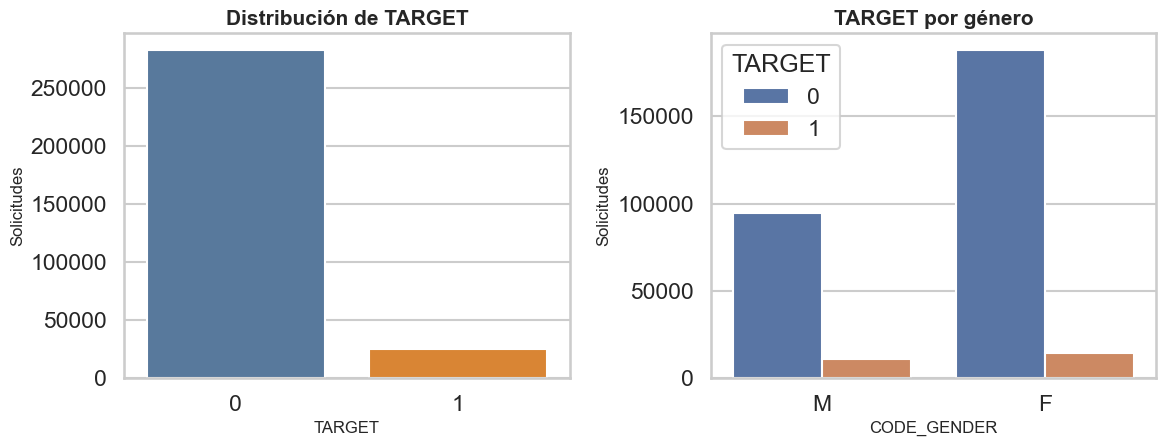

,variable,missing_rate
0,EXT_SOURCE_1,0.563812
1,EXT_SOURCE_3,0.198256
2,EXT_SOURCE_2,0.002146


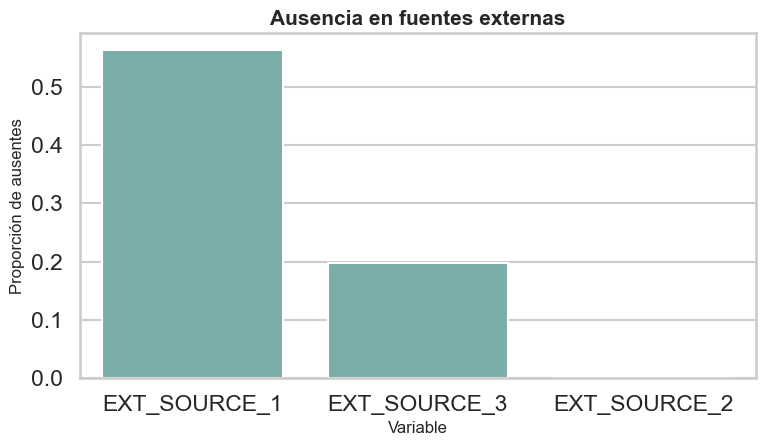

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.countplot(data=raw_fm, x="TARGET", ax=axes[0], palette=["#4C78A8", "#F58518"])
axes[0].set_title("Distribución de TARGET")
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Solicitudes")

sns.countplot(data=raw_fm, x="CODE_GENDER", hue="TARGET", ax=axes[1])
axes[1].set_title("TARGET por género")
axes[1].set_xlabel("CODE_GENDER")
axes[1].set_ylabel("Solicitudes")
save_run_figure(fig, "eda_target_gender.png")
plt.show()

ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
missing_ext = raw_fm[ext_cols].isna().mean().sort_values(ascending=False).reset_index()
missing_ext.columns = ["variable", "missing_rate"]
display(missing_ext)

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=missing_ext, x="variable", y="missing_rate", color="#72B7B2", ax=ax)
ax.set_title("Ausencia en fuentes externas")
ax.set_xlabel("Variable")
ax.set_ylabel("Proporción de ausentes")
save_run_figure(fig, "eda_ext_source_missingness.png")
plt.show()


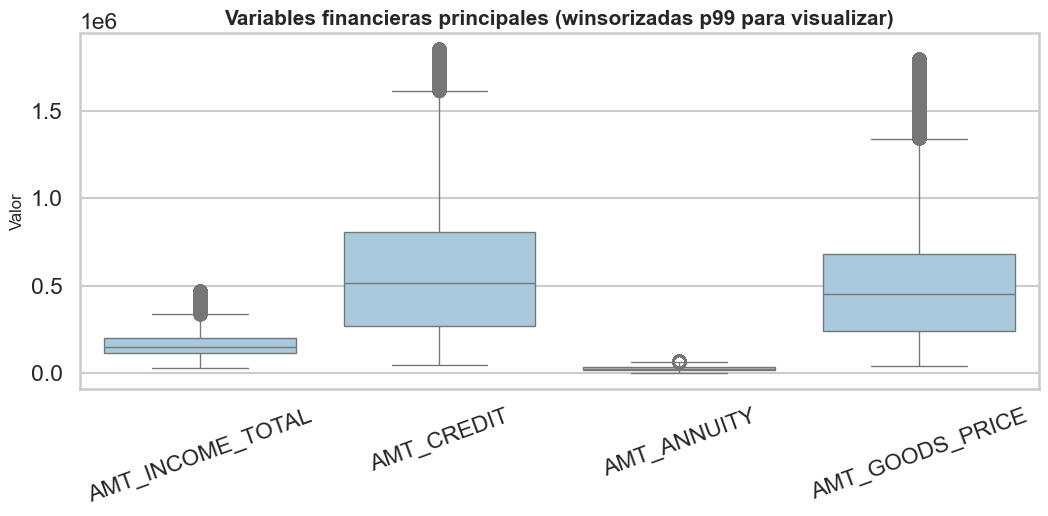

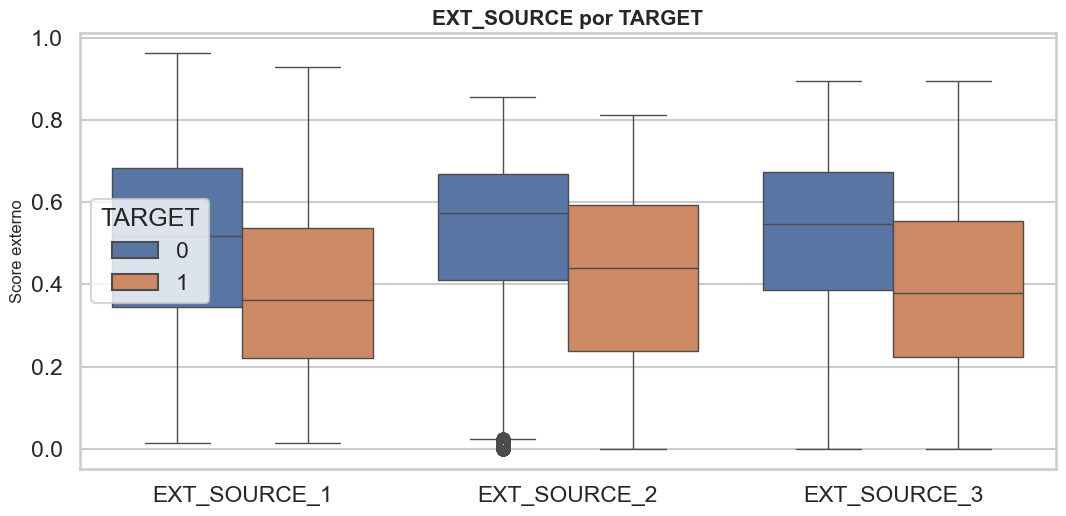

In [5]:
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
financial_long = raw_fm[financial_cols].clip(
    upper=raw_fm[financial_cols].quantile(0.99),
    axis=1,
).melt(var_name="variable", value_name="valor_winsorizado_p99")

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=financial_long, x="variable", y="valor_winsorizado_p99", color="#A0CBE8", ax=ax)
ax.set_title("Variables financieras principales (winsorizadas p99 para visualizar)")
ax.set_xlabel("")
ax.set_ylabel("Valor")
ax.tick_params(axis="x", rotation=20)
save_run_figure(fig, "eda_financial_boxplots.png")
plt.show()

ext_by_target = raw_fm.melt(
    id_vars="TARGET",
    value_vars=ext_cols,
    var_name="variable",
    value_name="score",
).dropna()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=ext_by_target, x="variable", y="score", hue="TARGET", ax=ax)
ax.set_title("EXT_SOURCE por TARGET")
ax.set_xlabel("")
ax.set_ylabel("Score externo")
save_run_figure(fig, "eda_ext_source_by_target.png")
plt.show()


,decil,solicitudes,target_rate,score_min,score_max,variable
0,1,13414,0.1756,0.0146,0.2125,EXT_SOURCE_1
1,2,13413,0.1159,0.2125,0.2963,EXT_SOURCE_1
2,3,13414,0.0909,0.2963,0.3693,EXT_SOURCE_1
3,4,13412,0.0838,0.3693,0.4381,EXT_SOURCE_1
4,5,13414,0.0669,0.4381,0.5060,EXT_SOURCE_1
5,6,13412,0.0602,0.5060,0.5732,EXT_SOURCE_1
6,7,13413,0.0514,0.5732,0.6404,EXT_SOURCE_1
7,8,13415,0.0438,0.6404,0.7101,EXT_SOURCE_1
8,9,13411,0.0351,0.7101,0.7867,EXT_SOURCE_1
9,10,13413,0.0257,0.7867,0.9627,EXT_SOURCE_1


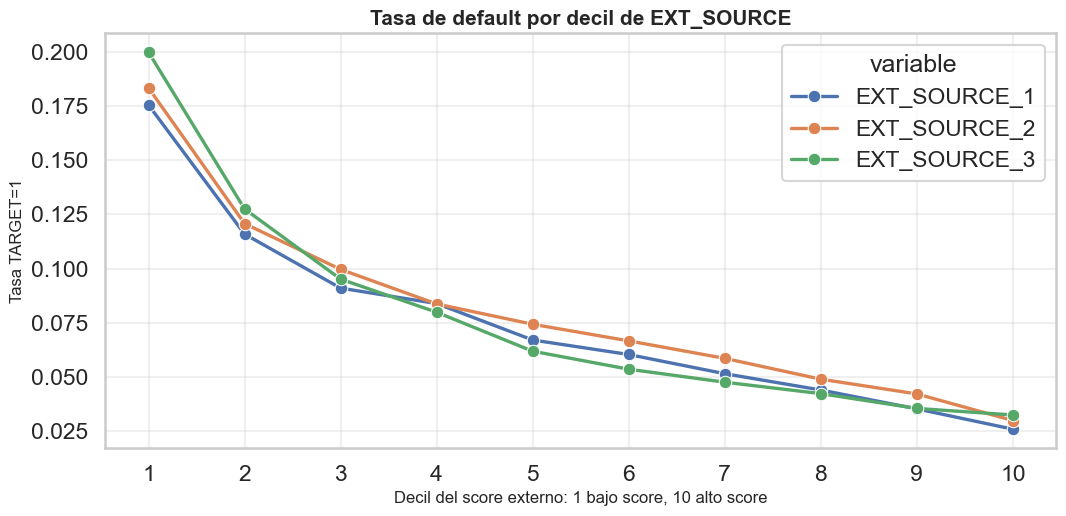

In [6]:
def default_rate_by_decile(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Calcula la tasa de default por decil para cada fuente externa."""
    rows = []
    for column in columns:
        subset = frame[[column, "TARGET"]].dropna().copy()
        subset["decil"] = pd.qcut(subset[column], q=10, labels=False, duplicates="drop")
        grouped = (
            subset.groupby("decil", observed=True)
            .agg(
                solicitudes=("TARGET", "size"),
                target_rate=("TARGET", "mean"),
                score_min=(column, "min"),
                score_max=(column, "max"),
            )
            .reset_index()
        )
        grouped["decil"] = grouped["decil"].astype(int) + 1
        grouped["variable"] = column
        rows.append(grouped)
    return pd.concat(rows, ignore_index=True)

ext_deciles = default_rate_by_decile(raw_fm, ext_cols)
ext_deciles_display = ext_deciles.copy()
for column in ["target_rate", "score_min", "score_max"]:
    ext_deciles_display[column] = ext_deciles_display[column].round(4)
display(ext_deciles_display)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(
    data=ext_deciles,
    x="decil",
    y="target_rate",
    hue="variable",
    marker="o",
    linewidth=2.4,
    ax=ax,
)
ax.set_title("Tasa de default por decil de EXT_SOURCE")
ax.set_xlabel("Decil del score externo: 1 bajo score, 10 alto score")
ax.set_ylabel("Tasa TARGET=1")
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.30)
save_run_figure(fig, "eda_ext_source_deciles_default_rate.png")
plt.show()


,observación,implicación técnica
0,TARGET está desbalanceado,No usamos accuracy como métrica principal; rep...
1,CODE_GENDER puede asociarse a tasas distintas ...,Entrenamos y auditamos una familia FAIR con pe...
2,EXT_SOURCE contiene ausencias relevantes,Conservamos EXT_NULL_COUNT crudo y lo cruzamos...
3,Los importes financieros tienen colas largas,La arquitectura custom usa ratios y transforma...


,EXT_NULL_COUNT,solicitudes,target_rate,male_rate
0,0,109587,0.072983,0.314663
1,1,161011,0.081783,0.348442
2,2,36737,0.099219,0.393173
3,3,172,0.081395,0.168605


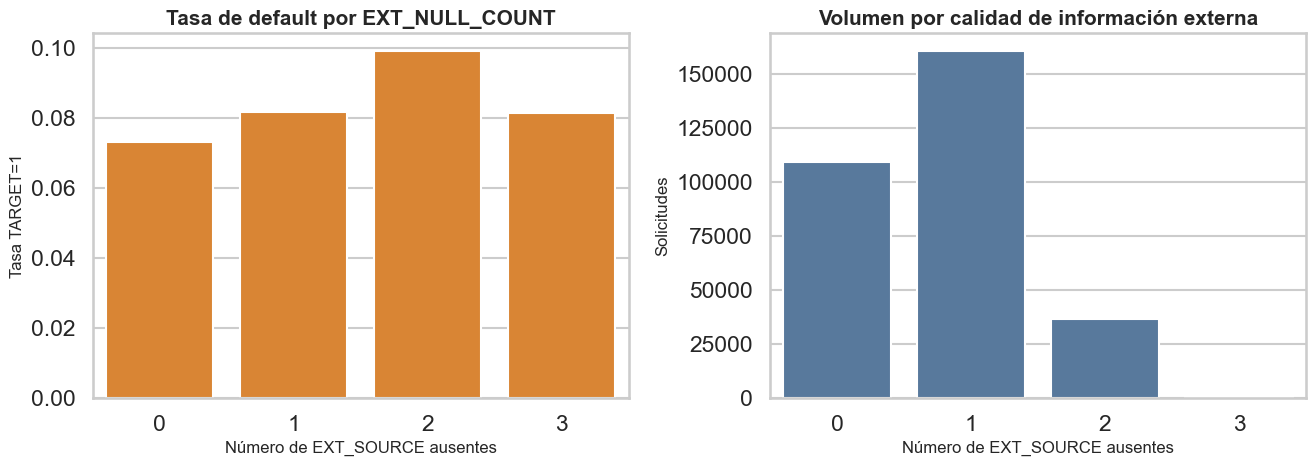

In [7]:
ext_null_count_eda = raw_fm[ext_cols].isna().sum(axis=1).astype(int)
eda_decisions = pd.DataFrame([
    {
        "observación": "TARGET está desbalanceado",
        "implicación técnica": "No usamos accuracy como métrica principal; reportamos ROC-AUC y PR-AUC.",
    },
    {
        "observación": "CODE_GENDER puede asociarse a tasas distintas de default",
        "implicación técnica": "Entrenamos y auditamos una familia FAIR con penalización de dependencia.",
    },
    {
        "observación": "EXT_SOURCE contiene ausencias relevantes",
        "implicación técnica": "Conservamos EXT_NULL_COUNT crudo y lo cruzamos con la incertidumbre M2.",
    },
    {
        "observación": "Los importes financieros tienen colas largas",
        "implicación técnica": "La arquitectura custom usa ratios y transformaciones robustas de importes.",
    },
])
display(eda_decisions)

ext_null_target = (
    raw_fm.assign(EXT_NULL_COUNT=ext_null_count_eda)
    .groupby("EXT_NULL_COUNT")
    .agg(
        solicitudes=("TARGET", "size"),
        target_rate=("TARGET", "mean"),
        male_rate=("CODE_GENDER", lambda values: (values == "M").mean()),
    )
    .reset_index()
)
display(ext_null_target)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
sns.barplot(data=ext_null_target, x="EXT_NULL_COUNT", y="target_rate", color="#F58518", ax=axes[0])
axes[0].set_title("Tasa de default por EXT_NULL_COUNT")
axes[0].set_xlabel("Número de EXT_SOURCE ausentes")
axes[0].set_ylabel("Tasa TARGET=1")

sns.barplot(data=ext_null_target, x="EXT_NULL_COUNT", y="solicitudes", color="#4C78A8", ax=axes[1])
axes[1].set_title("Volumen por calidad de información externa")
axes[1].set_xlabel("Número de EXT_SOURCE ausentes")
axes[1].set_ylabel("Solicitudes")
save_run_figure(fig, "eda_ext_null_count_target_rate.png")
plt.show()


## <font color="#0099CC">**3. Preprocesamiento sin leakage**</font>

El preprocesamiento se ejecuta dentro de una clase POO para mantener el flujo auditable. Primero se aplican transformaciones deterministas, después se hace el split estratificado y solo entonces se ajustan imputadores, escaladores y codificadores sobre train.

Una parte crítica es `EXT_NULL_COUNT`: el modelo puede usar matrices escaladas, pero los reportes de incertidumbre necesitan el valor semántico crudo `0`, `1`, `2`, `3`. Por eso se preserva explícitamente en el dataset procesado.


,split,n,target_rate,sensitive_rate,target_0_sensitive_0,target_0_sensitive_1,target_1_sensitive_0,target_1_sensitive_1
0,train,215254,0.080733,0.341648,131794,66082,9919,7459
1,validation,46126,0.080714,0.341651,28242,14161,2125,1598
2,test,46127,0.080734,0.341644,28242,14161,2126,1598


X_train: (215254, 36)
X_val: (46126, 36)
X_test: (46127, 36)
Número de features procesadas: 36


,count
EXT_NULL_COUNT,
0,16448
1,24140
2,5511
3,28


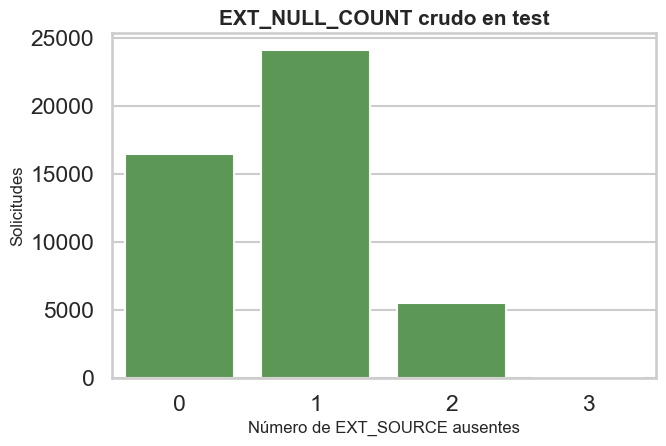

In [8]:
if not RUN_FULL_PIPELINE:
    raise RuntimeError("RUN_FULL_PIPELINE=False. Actívalo para ejecutar el MVP completo desde cero.")

data_result = workflow.prepare_data(APPLICATION_TRAIN)
processed = data_result.processed
split_report = data_result.split.report
feature_names = tuple(processed.feature_names)

display(split_report)
print("X_train:", processed.X_train.shape)
print("X_val:", processed.X_val.shape)
print("X_test:", processed.X_test.shape)
print("Número de features procesadas:", len(feature_names))

ext_values = pd.Series(processed.ext_null_count_test, name="EXT_NULL_COUNT").astype(int)
assert set(ext_values.unique()).issubset({0, 1, 2, 3})
display(ext_values.value_counts().sort_index().rename("count").to_frame())

fig, ax = plt.subplots(figsize=(7, 4.8))
sns.countplot(x=ext_values, color="#54A24B", ax=ax)
ax.set_title("EXT_NULL_COUNT crudo en test")
ax.set_xlabel("Número de EXT_SOURCE ausentes")
ax.set_ylabel("Solicitudes")
save_run_figure(fig, "preprocessing_ext_null_count.png")
plt.show()


## <font color="#0099CC">**4. Arquitectura custom, AutoML y aprendizaje justo**</font>

La red combina información financiera y variable sensible de forma controlada. La arquitectura incorpora transformaciones específicas del dominio financiero y una pérdida FAIR que penaliza la dependencia entre predicción y género.

El proceso tiene dos fases:

1. **Keras Tuner** busca una topología razonable bajo presión FAIR moderada.
2. **Barrido de `lambda_fair`** entrena una familia de modelos para observar el intercambio entre rendimiento predictivo y dependencia con género.

Esta sección es costosa: aquí se ejecutan los trials de AutoML y el entrenamiento de los modelos de la curva de Pareto.


In [9]:
search_result, sweep_result = workflow.train_tuner_and_sweep(
    processed,
    verbose=1,
)

pareto_run = pd.read_csv(paths.pareto_results_csv)
pareto = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "pareto_results.csv")

required_cols = {"lambda_fair", "val_auc", "val_abs_rho", "val_f1", "selected_for_test"}
missing_cols = required_cols.difference(pareto.columns)
if missing_cols:
    raise ValueError(f"Pareto inválida. Faltan columnas: {sorted(missing_cols)}")

expected_lambdas = set(float(value) for value in LAMBDA_VALUES)
observed_lambdas = set(float(value) for value in pareto["lambda_fair"])
assert expected_lambdas.issubset(observed_lambdas)

print("Mejor arquitectura encontrada por Keras Tuner:")
print(search_result.best_config)
print("Pareto guardada en:", paths.pareto_results_csv)
display(pareto)


Trial 15 Complete [00h 01m 09s]
val_auc: 0.7372682094573975

Best val_auc So Far: 0.7440946102142334
Total elapsed time: 00h 14m 47s
Epoch 1/50
211/211 [==============================] - 4s 12ms/step - loss: 0.6145 - auc: 0.7246 - pr_auc: 0.1960 - binary_accuracy: 0.6610 - precision: 0.1484 - recall: 0.6755 - val_loss: 0.6436 - val_auc: 0.7330 - val_pr_auc: 0.2201 - val_binary_accuracy: 0.6343 - val_precision: 0.1432 - val_recall: 0.7086 - lr: 9.7804e-04 - val_abs_rho: 0.0759
Epoch 2/50
211/211 [==============================] - 2s 10ms/step - loss: 0.6051 - auc: 0.7357 - pr_auc: 0.2041 - binary_accuracy: 0.6736 - precision: 0.1539 - recall: 0.6764 - val_loss: 0.6182 - val_auc: 0.7348 - val_pr_auc: 0.2244 - val_binary_accuracy: 0.6580 - val_precision: 0.1493 - val_recall: 0.6895 - lr: 9.7804e-04 - val_abs_rho: 0.0814
Epoch 3/50
211/211 [==============================] - 2s 10ms/step - loss: 0.6021 - auc: 0.7392 - pr_auc: 0.2103 - binary_accuracy: 0.6772 - precision: 0.1562 - recall: 0.

,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
0,0.00,0.745716,0.236724,0.102056,0.487734,0.671270,0.154881,0.689498,0.252944,41,results/runs/20260624_214719/models/fair_lambd...,results/runs/20260624_214719/tables/history_fa...,True
1,0.05,0.745386,0.235332,0.087257,0.452407,0.629753,0.146038,0.739995,0.243935,49,results/runs/20260624_214719/models/fair_lambd...,results/runs/20260624_214719/tables/history_fa...,False
2,0.10,0.745700,0.234796,0.082095,0.499283,0.683519,0.158126,0.675530,0.256267,41,results/runs/20260624_214719/models/fair_lambd...,results/runs/20260624_214719/tables/history_fa...,False
3,0.25,0.744769,0.235494,0.062910,0.528642,0.712396,0.166585,0.640344,0.264389,41,results/runs/20260624_214719/models/fair_lambd...,results/runs/20260624_214719/tables/history_fa...,False
4,0.50,0.743830,0.234556,0.041204,0.519691,0.703790,0.164189,0.652699,0.262377,41,results/runs/20260624_214719/models/fair_lambd...,results/runs/20260624_214719/tables/history_fa...,False
5,1.00,0.743023,0.233763,0.028334,0.505926,0.688267,0.159248,0.668815,0.257245,40,results/runs/20260624_214719/models/fair_lambd...,results/runs/20260624_214719/tables/history_fa...,False
6,2.00,0.742413,0.232002,0.015506,0.493002,0.679270,0.157351,0.682783,0.255760,34,results/runs/20260624_214719/models/fair_lambd...,results/runs/20260624_214719/tables/history_fa...,False
7,5.00,0.740806,0.231569,0.003597,0.502446,0.681525,0.157345,0.676336,0.255298,41,results/runs/20260624_214719/models/fair_lambd...,results/runs/20260624_214719/tables/history_fa...,True


## <font color="#0099CC">**5. Curva de Pareto FAIR**</font>

La curva de Pareto resume la decisión principal del aprendizaje justo. El eje X mide dependencia con género: cuanto más a la izquierda, menor dependencia. El eje Y mide ROC-AUC en validation: cuanto más arriba, mejor ranking predictivo.

El modelo FAIR final no se elige por maximizar una única métrica, sino por representar un compromiso defendible: reducir mucho la dependencia con género pagando una caída moderada de AUC.


,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
0,0.00,0.745874,0.236014,0.098362,0.481516,0.661839,0.152960,0.702928,0.251248,49,results/models/fair_lambda_0_0.keras,results/tables/history_fair_lambda_0_0.csv,True
1,0.05,0.745863,0.234721,0.089805,0.532670,0.732147,0.173870,0.618050,0.271392,31,results/models/fair_lambda_0_05.keras,results/tables/history_fair_lambda_0_05.csv,False
2,0.10,0.745624,0.236025,0.082708,0.519312,0.703703,0.163963,0.651625,0.262001,41,results/models/fair_lambda_0_1.keras,results/tables/history_fair_lambda_0_1.csv,False
3,0.25,0.745037,0.234187,0.060413,0.456856,0.629493,0.145945,0.739995,0.243805,41,results/models/fair_lambda_0_25.keras,results/tables/history_fair_lambda_0_25.csv,False
4,0.50,0.744002,0.234088,0.042580,0.516657,0.703833,0.164030,0.651625,0.262086,41,results/models/fair_lambda_0_5.keras,results/tables/history_fair_lambda_0_5.csv,False
5,1.00,0.742858,0.233438,0.025724,0.506618,0.688332,0.159540,0.670427,0.257745,41,results/models/fair_lambda_1_0.keras,results/tables/history_fair_lambda_1_0.csv,False
6,2.00,0.742150,0.232905,0.014460,0.508977,0.698283,0.162137,0.656997,0.260088,34,results/models/fair_lambda_2_0.keras,results/tables/history_fair_lambda_2_0.csv,False
7,5.00,0.740213,0.230716,0.009827,0.500768,0.681698,0.157296,0.675530,0.255175,30,results/models/fair_lambda_5_0.keras,results/tables/history_fair_lambda_5_0.csv,True


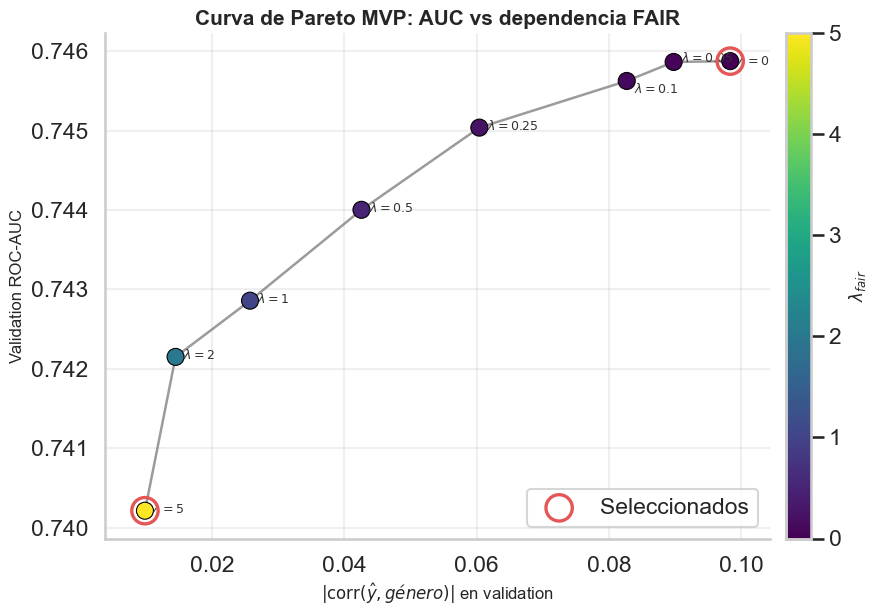

In [17]:
pareto = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "pareto_results.csv")
pareto_plot = pareto.sort_values("lambda_fair").copy()
display(pareto_plot)

fig, ax = plt.subplots(figsize=(9.5, 6.5))

# La línea conecta los modelos en el orden del barrido lambda_fair.
ax.plot(
    pareto_plot["val_abs_rho"],
    pareto_plot["val_auc"],
    color="#7A7A7A",
    linewidth=1.8,
    alpha=0.75,
    zorder=1,
)

scatter = ax.scatter(
    pareto_plot["val_abs_rho"],
    pareto_plot["val_auc"],
    c=pareto_plot["lambda_fair"],
    cmap="viridis",
    s=150,
    edgecolors="black",
    linewidths=0.8,
    zorder=2,
)

label_offsets = {
    0.0: (0.0011, 0.00000),
    0.05: (0.0011, 0.00005),
    0.1: (0.0011, -0.00010),
    0.25: (0.0011, 0.00002),
    0.5: (0.0011, 0.00002),
    1.0: (0.0011, 0.00002),
    2.0: (0.0011, 0.00002),
    5.0: (0.0011, 0.00002),
}

for _, row in pareto_plot.iterrows():
    lam = float(row["lambda_fair"])
    dx, dy = label_offsets.get(lam, (0.0011, 0.0))
    ax.text(
        row["val_abs_rho"] + dx,
        row["val_auc"] + dy,
        rf"$\lambda={lam:g}$",
        fontsize=9,
        ha="left",
        va="center",
        color="#333333",
        zorder=3,
    )

selected = pareto_plot[pareto_plot["selected_for_test"].astype(bool)]
ax.scatter(
    selected["val_abs_rho"],
    selected["val_auc"],
    s=360,
    facecolors="none",
    edgecolors="#E45756",
    linewidths=2.4,
    label="Seleccionados",
    zorder=4,
)

x_padding = 0.006
y_padding = 0.00035
ax.set_xlim(max(0.0, pareto_plot["val_abs_rho"].min() - x_padding), pareto_plot["val_abs_rho"].max() + x_padding)
ax.set_ylim(pareto_plot["val_auc"].min() - y_padding, pareto_plot["val_auc"].max() + y_padding)
ax.set_title("Curva de Pareto MVP: AUC vs dependencia FAIR", fontsize=15, weight="bold")
ax.set_xlabel(r"$|\mathrm{corr}(\hat{y}, género)|$ en validation")
ax.set_ylabel("Validation ROC-AUC")
ax.grid(alpha=0.30)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label(r"$\lambda_{fair}$", rotation=90)

ax.legend(loc="lower right", frameon=True)
sns.despine()
save_run_figure(fig, "pareto_auc_vs_fairness.png")
plt.show()


## <font color="#0099CC">**6. Curvas de convergencia**</font>

Las curvas de loss y AUC verifican que los modelos seleccionados no son puntos aislados de una tabla: ambos han sido entrenados y monitorizados. Se comparan el modelo base y el modelo FAIR final con sus métricas de train y validation.


,loss,val_loss,auc,val_auc
40,0.588791,0.592131,0.753811,0.745468
81,0.597307,0.602741,0.749273,0.740442


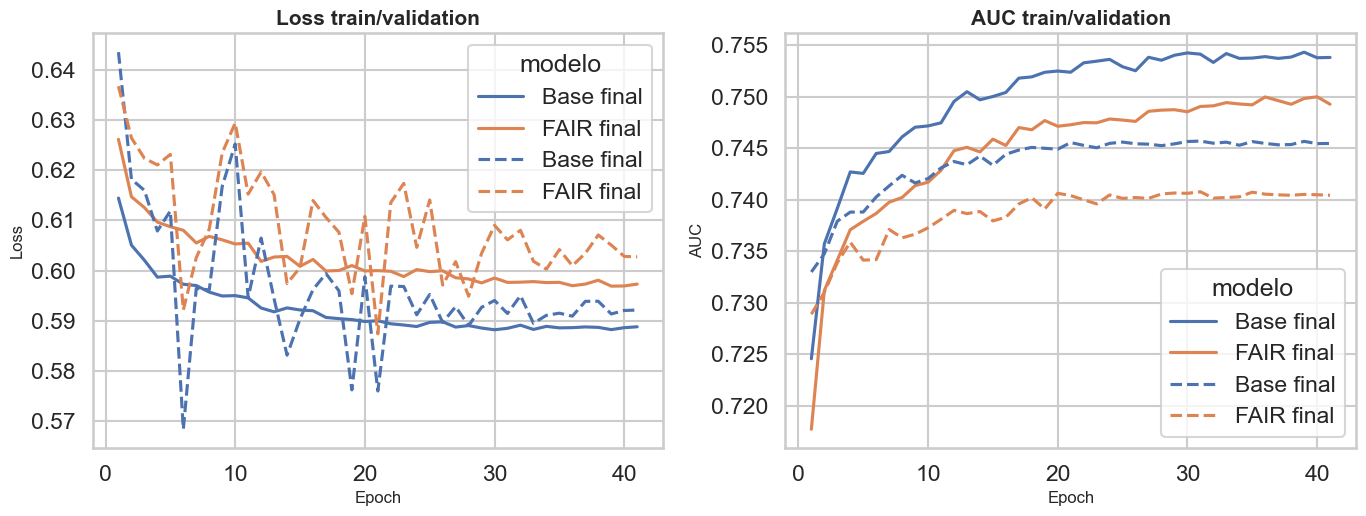

In [11]:
base_row = pareto[
    pareto["selected_for_test"].astype(bool) & np.isclose(pareto["lambda_fair"].astype(float), 0.0)
].iloc[0]
fair_row = pareto[
    pareto["selected_for_test"].astype(bool) & ~np.isclose(pareto["lambda_fair"].astype(float), 0.0)
].iloc[0]

history_paths = {
    "Base final": PROJECT_ROOT / base_row["history_path"],
    "FAIR final": PROJECT_ROOT / fair_row["history_path"],
}

histories = []
for model_name, path in history_paths.items():
    if not path.exists():
        raise FileNotFoundError(path)
    history = pd.read_csv(path)
    history["modelo"] = model_name
    history["epoch"] = np.arange(1, len(history) + 1)
    histories.append(history)

history_df = pd.concat(histories, ignore_index=True)
display(history_df.groupby("modelo")[["loss", "val_loss", "auc", "val_auc"]].tail(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.lineplot(data=history_df, x="epoch", y="loss", hue="modelo", ax=axes[0])
sns.lineplot(data=history_df, x="epoch", y="val_loss", hue="modelo", ax=axes[0], linestyle="--")
axes[0].set_title("Loss train/validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

sns.lineplot(data=history_df, x="epoch", y="auc", hue="modelo", ax=axes[1])
sns.lineplot(data=history_df, x="epoch", y="val_auc", hue="modelo", ax=axes[1], linestyle="--")
axes[1].set_title("AUC train/validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
save_run_figure(fig, "training_curves_base_vs_fair.png")
plt.show()


## <font color="#0099CC">**7. Evaluación final en test**</font>

El conjunto de test solo se usa al final. Se reportan métricas predictivas y métricas de justicia porque el objetivo no es maximizar AUC a cualquier precio: el sistema debe predecir, reducir dependencia con género y mantener una lectura clara del coste de esa restricción.

- **ROC-AUC** mide capacidad de ranking.
- **PR-AUC** es más informativa cuando la clase positiva es minoritaria.
- **Recall** indica cuántos casos de dificultad de pago se capturan.
- **`abs_rho`**, **DPD** y **EOD** auditan dependencia y diferencias de comportamiento entre grupos.


,modelo,lambda_fair,threshold,auc,pr_auc,accuracy,precision,recall,f1,abs_rho,dpd,eod
0,Base final,0.0,0.487734,0.743811,0.223342,0.666139,0.153778,0.696294,0.251919,0.100951,0.090622,0.081288
1,FAIR final,5.0,0.502446,0.738011,0.218635,0.673033,0.153931,0.678303,0.250919,0.002211,0.022133,0.011903


Tabla test guardada en: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719\tables\test_results_base_vs_fair.csv


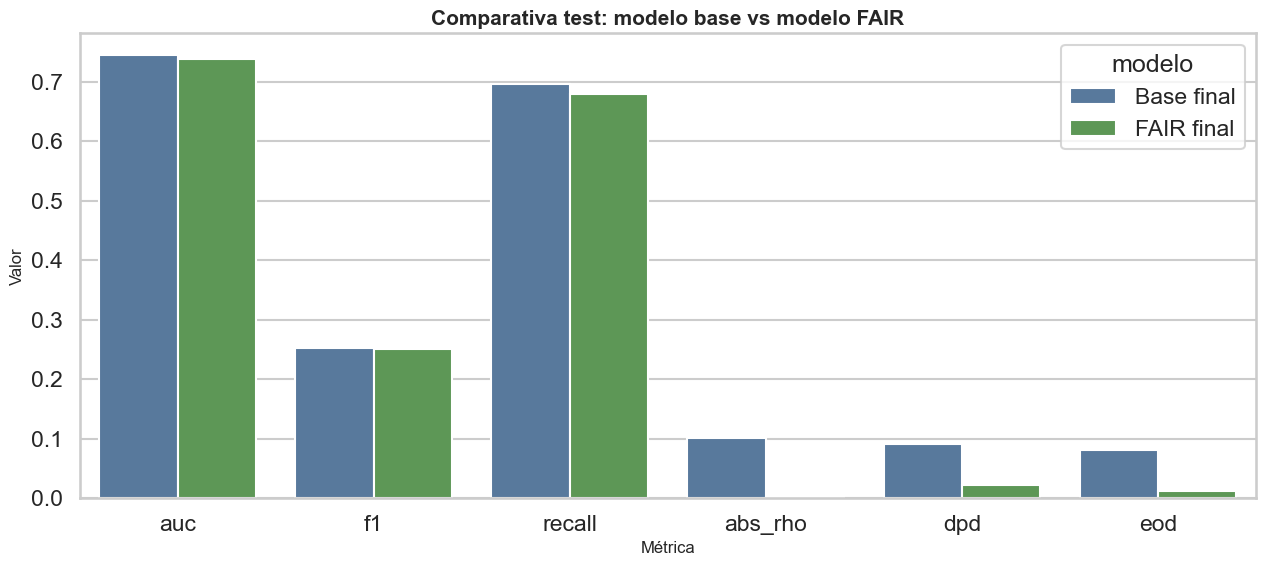

Delta AUC FAIR-base: -0.0058
Reducción |rho|: 0.0987
Reducción DPD: 0.0685
Reducción EOD: 0.0694


In [12]:
evaluation = workflow.evaluate_selected_models(processed, pareto)
test_results = evaluation.table

display(test_results)
print("Tabla test guardada en:", paths.test_results_csv)

plot_df = test_results.melt(
    id_vars="modelo",
    value_vars=["auc", "f1", "recall", "abs_rho", "dpd", "eod"],
    var_name="métrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=plot_df, x="métrica", y="valor", hue="modelo", palette=["#4C78A8", "#54A24B"], ax=ax)
ax.set_title("Comparativa test: modelo base vs modelo FAIR")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
save_run_figure(fig, "test_metrics_base_vs_fair.png")
plt.show()

base = test_results[test_results["modelo"] == "Base final"].iloc[0]
fair = test_results[test_results["modelo"] == "FAIR final"].iloc[0]
print(f"Delta AUC FAIR-base: {fair['auc'] - base['auc']:.4f}")
print(f"Reducción |rho|: {base['abs_rho'] - fair['abs_rho']:.4f}")
print(f"Reducción DPD: {base['dpd'] - fair['dpd']:.4f}")
print(f"Reducción EOD: {base['eod'] - fair['eod']:.4f}")


## <font color="#0099CC">**8. Incertidumbre M2: aprender cuándo puede fallar M1**</font>

La incertidumbre principal sigue el enfoque indicado en clase: primero se entrena un clasificador `M1`; después se calcula el error absoluto de `M1` en validation y se entrena un segundo modelo `M2` para predecir ese error esperado.

En test, una incertidumbre alta significa que el perfil se parece a casos donde el clasificador suele equivocarse más. La salida de M2 usa `softplus`, normalización interna y validaciones defensivas para evitar el colapso a incertidumbre constante.


In [13]:
uncertainty_result = workflow.train_uncertainty(
    processed,
    pareto,
    verbose=1,
)

unc = uncertainty_result.prediction_result.predictions.copy()
unc_summary = uncertainty_result.prediction_result.summary.copy()
unc_ext = pd.read_csv(paths.uncertainty_by_ext_csv)

unc["EXT_NULL_COUNT"] = unc["EXT_NULL_COUNT"].astype(int)
assert unc["uncertainty"].nunique() > 1, "La incertidumbre no puede ser constante."
assert set(unc["EXT_NULL_COUNT"].unique()).issubset({0, 1, 2, 3})

display(unc[["SK_ID_CURR", "y_true", "y_pred_label", "sensitive", "uncertainty", "EXT_NULL_COUNT"]].head(10))
display(unc_summary)
display(unc_ext)
print("Uncertainty CSV:", paths.tables_dir / "uncertainty_test.csv")
print("EXT summary CSV:", paths.uncertainty_by_ext_csv)


Epoch 1/50
37/37 [==============================] - 1s 3ms/step - loss: 0.2692 - val_loss: 0.1516
Epoch 2/50
37/37 [==============================] - 0s 2ms/step - loss: 0.1892 - val_loss: 0.1175
Epoch 3/50
37/37 [==============================] - 0s 2ms/step - loss: 0.1634 - val_loss: 0.0978
Epoch 4/50
37/37 [==============================] - 0s 2ms/step - loss: 0.1420 - val_loss: 0.0841
Epoch 5/50
37/37 [==============================] - 0s 2ms/step - loss: 0.1254 - val_loss: 0.0757
Epoch 6/50
37/37 [==============================] - 0s 2ms/step - loss: 0.1121 - val_loss: 0.0690
Epoch 7/50
37/37 [==============================] - 0s 2ms/step - loss: 0.1002 - val_loss: 0.0638
Epoch 8/50
37/37 [==============================] - 0s 1ms/step - loss: 0.0921 - val_loss: 0.0603
Epoch 9/50
37/37 [==============================] - 0s 1ms/step - loss: 0.0853 - val_loss: 0.0574
Epoch 10/50
37/37 [==============================] - 0s 2ms/step - loss: 0.0801 - val_loss: 0.0549
Epoch 11/50
37/37 [

,SK_ID_CURR,y_true,y_pred_label,sensitive,uncertainty,EXT_NULL_COUNT
0,115177,0,0,0,0.425170,0
1,353727,0,0,0,0.245321,0
2,430036,0,1,1,0.682577,1
3,300897,0,1,0,0.745423,1
4,135159,0,0,1,0.356604,0
5,113415,0,1,1,0.546093,1
6,303073,0,0,0,0.245692,1
7,424584,1,1,0,0.716036,1
8,290763,0,0,1,0.184189,0
9,252578,0,1,0,0.524534,1


,y_true,count,uncertainty_mean,uncertainty_median,uncertainty_q1,uncertainty_q3,uncertainty_iqr
0,0,42403,0.411315,0.402602,0.258096,0.551856,0.293761
1,1,3724,0.569428,0.595778,0.454987,0.704016,0.249029


,EXT_NULL_COUNT,count,uncertainty_mean,uncertainty_median,uncertainty_q1,uncertainty_q3,uncertainty_iqr
0,0,16448,0.399928,0.380597,0.237757,0.546622,0.308865
1,1,24140,0.427250,0.421861,0.269861,0.571577,0.301716
2,2,5511,0.481600,0.485246,0.362059,0.602606,0.240547
3,3,28,0.557952,0.564663,0.506518,0.603472,0.096954


Uncertainty CSV: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719\tables\uncertainty_test.csv
EXT summary CSV: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719\tables\uncertainty_by_ext_null_count.csv


## <font color="#0099CC">**9. Figuras obligatorias de incertidumbre**</font>

El enunciado pide comparar la incertidumbre entre buen pagador y mal pagador. Aquí se muestran dos lecturas complementarias:

1. Distribución de incertidumbre por clase predicha y por `TARGET` real.
2. Relación entre incertidumbre y `EXT_NULL_COUNT`, que mide cuántas fuentes externas faltan.

Si el modelo es honesto, debería dudar más en perfiles difíciles y en perfiles con peor calidad de información externa.


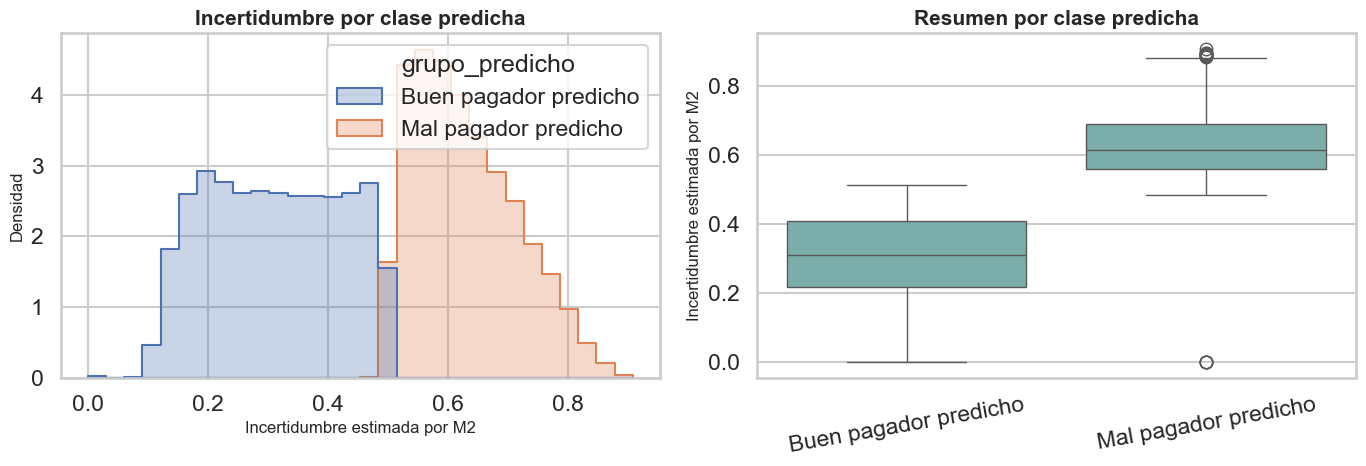

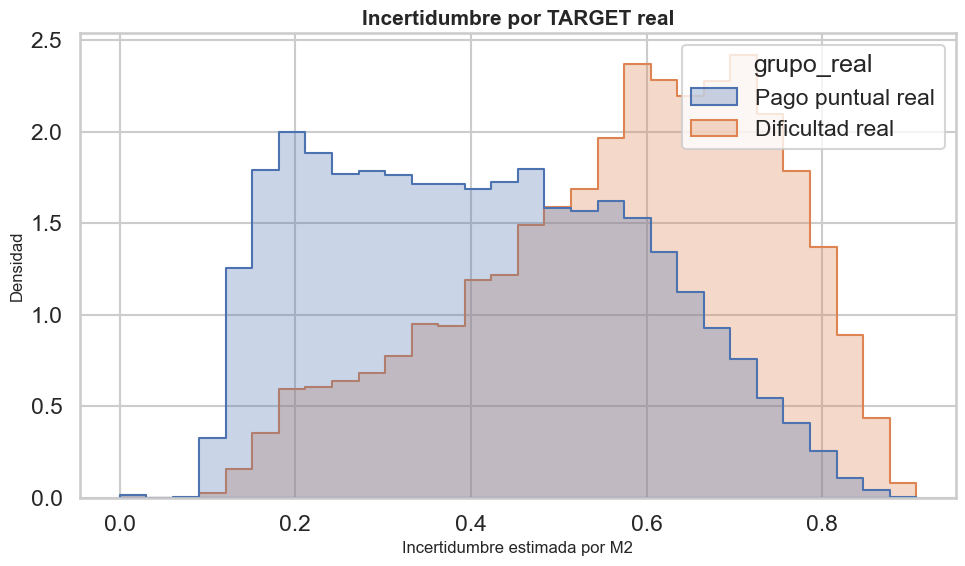

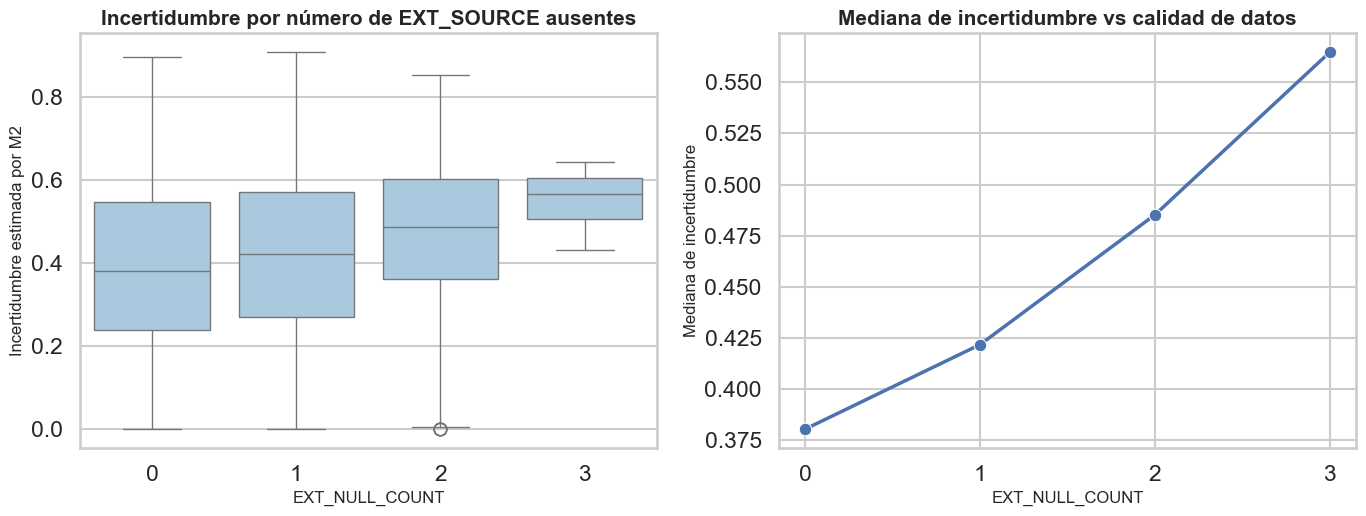

In [14]:
unc["grupo_predicho"] = unc["y_pred_label"].map({0: "Buen pagador predicho", 1: "Mal pagador predicho"})
unc["grupo_real"] = unc["y_true"].map({0: "Pago puntual real", 1: "Dificultad real"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=unc,
    x="uncertainty",
    hue="grupo_predicho",
    stat="density",
    common_norm=False,
    bins=30,
    element="step",
    fill=True,
    alpha=0.30,
    ax=axes[0],
)
axes[0].set_title("Incertidumbre por clase predicha")
axes[0].set_xlabel("Incertidumbre estimada por M2")
axes[0].set_ylabel("Densidad")

sns.boxplot(data=unc, x="grupo_predicho", y="uncertainty", color="#72B7B2", ax=axes[1])
axes[1].set_title("Resumen por clase predicha")
axes[1].set_xlabel("")
axes[1].set_ylabel("Incertidumbre estimada por M2")
axes[1].tick_params(axis="x", rotation=10)
save_run_figure(fig, "uncertainty_distribution_by_predicted_class.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=unc,
    x="uncertainty",
    hue="grupo_real",
    stat="density",
    common_norm=False,
    bins=30,
    element="step",
    fill=True,
    alpha=0.30,
    ax=ax,
)
ax.set_title("Incertidumbre por TARGET real")
ax.set_xlabel("Incertidumbre estimada por M2")
ax.set_ylabel("Densidad")
save_run_figure(fig, "uncertainty_distribution_by_target.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=unc, x="EXT_NULL_COUNT", y="uncertainty", color="#A0CBE8", ax=axes[0])
axes[0].set_title("Incertidumbre por número de EXT_SOURCE ausentes")
axes[0].set_xlabel("EXT_NULL_COUNT")
axes[0].set_ylabel("Incertidumbre estimada por M2")

sns.lineplot(data=unc_ext, x="EXT_NULL_COUNT", y="uncertainty_median", marker="o", linewidth=2.5, ax=axes[1])
axes[1].set_title("Mediana de incertidumbre vs calidad de datos")
axes[1].set_xlabel("EXT_NULL_COUNT")
axes[1].set_ylabel("Mediana de incertidumbre")
axes[1].set_xticks([0, 1, 2, 3])
save_run_figure(fig, "ext_null_count_vs_uncertainty.png")
plt.show()


## <font color="#0099CC">**10. Manifiesto, artefactos y conclusiones**</font>

El manifiesto del run deja trazabilidad mínima: hiperparámetros principales, carpeta de salida y métricas finales. Las conclusiones se basan en la ejecución recién generada, no en artefactos estáticos.


In [15]:
manifest_path = workflow.write_manifest({
    "base_auc": float(base["auc"]),
    "fair_auc": float(fair["auc"]),
    "base_abs_rho": float(base["abs_rho"]),
    "fair_abs_rho": float(fair["abs_rho"]),
    "uncertainty_unique_values": int(unc["uncertainty"].nunique()),
})

artifact_summary = pd.DataFrame([
    {"artefacto": "Pareto", "ruta": paths.to_project_relative(paths.pareto_results_csv)},
    {"artefacto": "Test results", "ruta": paths.to_project_relative(paths.test_results_csv)},
    {"artefacto": "Uncertainty test", "ruta": paths.to_project_relative(paths.tables_dir / "uncertainty_test.csv")},
    {"artefacto": "Uncertainty by EXT_NULL_COUNT", "ruta": paths.to_project_relative(paths.uncertainty_by_ext_csv)},
    {"artefacto": "Figuras", "ruta": paths.to_project_relative(paths.figures_dir)},
    {"artefacto": "Modelos", "ruta": paths.to_project_relative(paths.models_dir)},
    {"artefacto": "Manifest", "ruta": paths.to_project_relative(manifest_path)},
])
display(artifact_summary)

conclusion = pd.DataFrame([
    {"resultado": "AUC base", "valor": base["auc"]},
    {"resultado": "AUC FAIR", "valor": fair["auc"]},
    {"resultado": "|rho| base", "valor": base["abs_rho"]},
    {"resultado": "|rho| FAIR", "valor": fair["abs_rho"]},
    {"resultado": "DPD base", "valor": base["dpd"]},
    {"resultado": "DPD FAIR", "valor": fair["dpd"]},
    {"resultado": "EOD base", "valor": base["eod"]},
    {"resultado": "EOD FAIR", "valor": fair["eod"]},
    {"resultado": "Valores únicos de incertidumbre", "valor": unc["uncertainty"].nunique()},
])
display(conclusion)

print("Resumen defendible:")
print(f"- El modelo FAIR reduce |rho| de {base['abs_rho']:.4f} a {fair['abs_rho']:.4f}.")
print(f"- La pérdida de AUC es {base['auc'] - fair['auc']:.4f}.")
print(f"- La incertidumbre tiene {unc['uncertainty'].nunique()} valores únicos; no está colapsada.")
print("- EXT_NULL_COUNT conserva valores semánticos 0, 1, 2, 3.")
print("- Run reproducible completo guardado en:", paths.run_dir)


,artefacto,ruta
0,Pareto,results/runs/20260624_214719/tables/pareto_res...
1,Test results,results/runs/20260624_214719/tables/test_resul...
2,Uncertainty test,results/runs/20260624_214719/tables/uncertaint...
3,Uncertainty by EXT_NULL_COUNT,results/runs/20260624_214719/tables/uncertaint...
4,Figuras,results/runs/20260624_214719/figures
5,Modelos,results/runs/20260624_214719/models
6,Manifest,results/runs/20260624_214719/run_manifest.csv


,resultado,valor
0,AUC base,0.743811
1,AUC FAIR,0.738011
2,|rho| base,0.100951
3,|rho| FAIR,0.002211
4,DPD base,0.090622
5,DPD FAIR,0.022133
6,EOD base,0.081288
7,EOD FAIR,0.011903
8,Valores únicos de incertidumbre,46052.000000


Resumen defendible:
- El modelo FAIR reduce |rho| de 0.1010 a 0.0022.
- La pérdida de AUC es 0.0058.
- La incertidumbre tiene 46052 valores únicos; no está colapsada.
- EXT_NULL_COUNT conserva valores semánticos 0, 1, 2, 3.
- Run reproducible completo guardado en: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\runs\20260624_214719
